In [1]:
#Load librabry
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

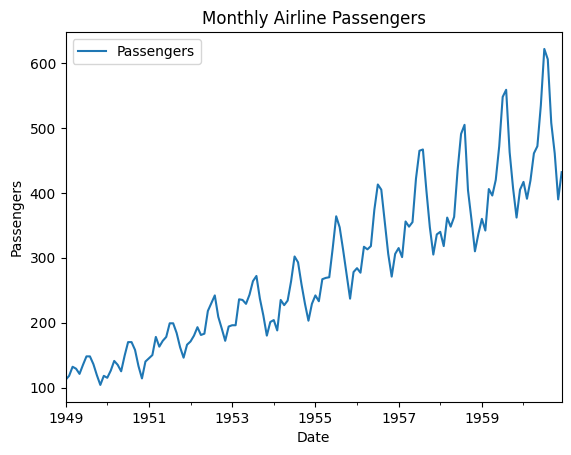

In [3]:
df.plot()
plt.title("Monthly Airline Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.show()

In [4]:
# Test for stationary
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Passengers'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641


In [5]:
#here our p value is > than 0.05 so e fail to reject null hy.
#If p-value > 0.05: Not stationary → Differencing needed

<Axes: xlabel='Month'>

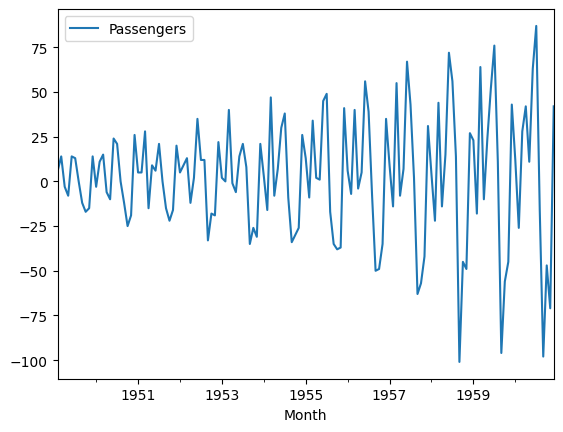

In [6]:
df_diff = df.diff().dropna()
df_diff.plot()

In [7]:
#MA(2)
from statsmodels.tsa.arima.model import ARIMA
model_ma = ARIMA(df, order=(0,1,2))
ma_fit = model_ma.fit()
print(ma_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(0, 1, 2)   Log Likelihood                -695.547
Date:                Mon, 25 Aug 2025   AIC                           1397.093
Time:                        06:38:03   BIC                           1405.982
Sample:                    01-01-1949   HQIC                          1400.705
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.3822      0.072      5.283      0.000       0.240       0.524
ma.L2         -0.2633      0.062     -4.256      0.000      -0.384      -0.142
sigma2       979.2956    111.655      8.771      0.0

In [8]:
#AR(3)
model_ar = AutoReg(df['Passengers'], lags=3)
ar_fit = model_ar.fit()
print(ar_fit.summary())

                            AutoReg Model Results                             
Dep. Variable:             Passengers   No. Observations:                  144
Model:                     AutoReg(3)   Log Likelihood                -684.430
Method:               Conditional MLE   S.D. of innovations             31.037
Date:                Mon, 25 Aug 2025   AIC                           1378.860
Time:                        06:38:03   BIC                           1393.603
Sample:                    04-01-1949   HQIC                          1384.851
                         - 12-01-1960                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            13.6410      6.872      1.985      0.047       0.172      27.110
Passengers.L1     1.3482      0.084     16.025      0.000       1.183       1.513
Passengers.L2    -0.5918      0.136     

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [9]:
#ARMA(2,2)
from statsmodels.tsa.arima.model import ARIMA
model_arma = ARIMA(df_diff, order=(2,0,2))  # (AR=2, I=0, MA=2)
arma_fit = model_arma.fit()
print(arma_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  143
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -666.022
Date:                Mon, 25 Aug 2025   AIC                           1344.044
Time:                        06:38:05   BIC                           1361.821
Sample:                    02-01-1949   HQIC                          1351.267
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5325      0.735      3.446      0.001       1.092       3.973
ar.L1          1.6478      0.028     58.901      0.000       1.593       1.703
ar.L2         -0.9094      0.025    -36.756      0.0

In [10]:
#ARIMA
model_arima = ARIMA(df['Passengers'], order=(2,1,2))
arima_fit = model_arima.fit()
print(arima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -671.673
Date:                Mon, 25 Aug 2025   AIC                           1353.347
Time:                        06:38:07   BIC                           1368.161
Sample:                    01-01-1949   HQIC                          1359.366
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6850      0.020     83.060      0.000       1.645       1.725
ar.L2         -0.9548      0.017    -55.420      0.000      -0.989      -0.921
ma.L1         -1.8432      0.124    -14.814      0.0

<Axes: xlabel='Month'>

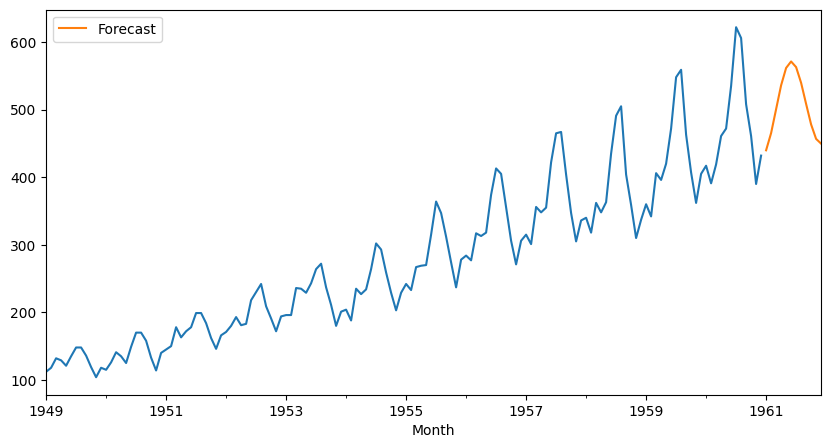

In [11]:
forecast = arima_fit.forecast(steps=12)
df['Passengers'].plot(label='Actual', figsize=(10,5))
forecast.plot(label='Forecast', legend=True)

In [13]:
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [12]:
from sklearn.metrics import mean_squared_error

# Example: split data
train = df[:120]
test = df[120:]
model = ARIMA(train, order=(2,1,2))
fit = model.fit()
forecast = fit.forecast(steps=len(test))
mse = mean_squared_error(test, forecast)
print(f'MSE: {mse:.2f}')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


MSE: 8225.46
